# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [1]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

In [2]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.geometry import LineString, Point
from shapely.affinity import rotate
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings
from inc import *
from shapely.ops import polygonize, unary_union

EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully


# Configuration

In [ ]:
tol_deg  = 5
street_length = 10
sampling_distance = 10 
dx = 0.5         # Thickness of each vertical bar
d_angles = -10 * np.ones(len(np.arange(0, 181, 10)))  # 10 degree rotation steps from 0 to 360 inclusive

# Query the surveys

In [4]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[1111]].copy()
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

l = 0
surveys = segments['SurveyId'].unique()
#survey = segments[segments['SurveyId'] == surveys[l]]
survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

# Algorithm starts here
## Prepare the surveys

In [5]:
# Compute the union of the survey geometries and simplify the result
#survey_union = survey_gdf.unary_union.simplify(10)  # Adjust tolerance 1.0 as needed
survey_union = survey_gdf.unary_union  # Adjust tolerance 1.0 as needed

# Create a GeoDataFrame from the union
survey_union_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union]},
    crs=survey_gdf.crs
)

# Make an offset of 10 (buffer by 10 units)
survey_union_offset_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union.buffer(street_length/2, cap_style=2)]},
    crs=survey_gdf.crs,
    geometry='geometry'
)

In [6]:
# Get the center as the midpoint of the bounds (average of min/max x/y)
minx, miny, maxx, maxy = survey_union_offset_gdf.total_bounds
center = Point((minx + maxx) / 2, (miny + maxy) / 2)
print("Center of the bounds:", center)

# Shift the survey_union_offset_gdf geometry so that the centroid is at (0, 0)
survey_union_offset_gdf['geometry'] = survey_union_offset_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)

Center of the bounds: POINT (351318.21332 5752405.9854)


In [7]:
survey_gdf['geometry'] = survey_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)
survey_gdf.set_geometry('geometry', inplace=True)


/tmp/ipykernel_72351/3853611118.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


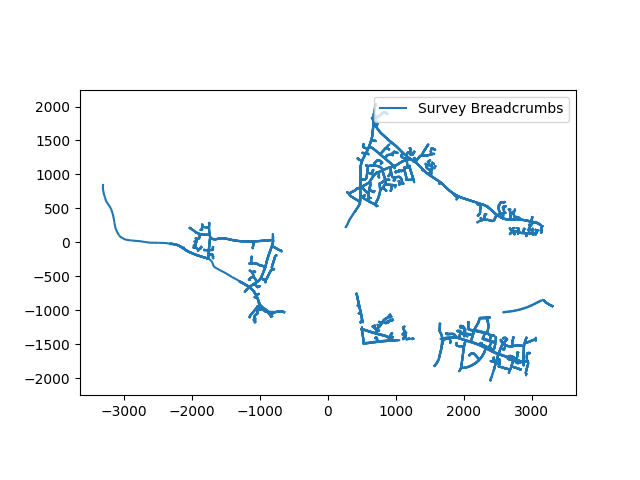

In [8]:
fig,ax = plt.subplots()
survey_gdf.plot(ax=ax, label='Survey Breadcrumbs')
survey_union_offset_gdf.plot(ax=ax, color='red', alpha=0.5, label='Street')
ax.legend()

# Generate the grid

In [9]:
# Assuming 'angle' and 'intersection_gdf' are in scope
def points_and_rotate(bottom, rot_angle):
    # Convert to Point, rotate each, and return as two tuples
    if isinstance(bottom, list) and all(isinstance(pt, tuple) and len(pt) == 2 for pt in bottom):
        rotated = [rotate(Point(pt), angle=rot_angle, origin=(0, 0)) for pt in bottom]
        if len(rotated) == 2:
            return (tuple(rotated[0].coords[0]), tuple(rotated[1].coords[0]))
    return (None, None)



In [10]:
import time
from shapely.geometry import MultiPoint
times = []
def get_max_min_points(df):
   min_x, min_y, max_x, max_y = MultiPoint(list(df['geometry'])).bounds
   return max_y - min_y

def get_nop(df):
    return df.shape[0]

start = time.perf_counter()
output_gdf = gpd.GeoDataFrame()
cumulative = 0
angle = 0
bounds = survey_union_offset_gdf.total_bounds
min_x, min_y, max_x, max_y = map(float, bounds)  # Ensure cast to float
r_x = np.sqrt(max_x**2 + max_y**2)
r_y = np.sqrt(min_x**2 + min_y**2)

# Compute number of columns safely and cast to int
num_cols = int(np.floor((2*r_x) / sampling_distance)) + 1

# Compute bar center x-positions
x_centers = np.linspace(-r_x, r_x, num=num_cols)

# For each center, form a thin rectangle
grid_lines = [
Polygon([
    (x - dx/2, r_y),
    (x + dx/2, r_y),
    (x + dx/2, -r_x),
    (x - dx/2, -r_x)
])
for x in x_centers
]
# Define the vector
vec = np.array([1,0])
ortho_vec = np.array([0,1])
grid_lines_gdf = gpd.GeoDataFrame({'geometry': grid_lines}, crs=survey_gdf.crs, geometry='geometry')
grid_lines_gdf['grid_idx'] = grid_lines_gdf.index
init_time = time.perf_counter()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    current_vec = vec   
    current_ortho_vec = ortho_vec
    for d_angle in d_angles:
            print('Processing angle: ', angle)
            # Rotate the map
            start_rotate = time.perf_counter()
            if angle == 0:
                contour_gdf = survey_union_offset_gdf.copy()
                survey_rotated_gdf = survey_gdf.copy()
            else:
                contour_gdf['geometry'] = contour_gdf['geometry'].rotate(angle=-d_angle, origin=(0,0))
                survey_rotated_gdf['geometry'] = survey_rotated_gdf['geometry'].rotate(angle=-d_angle, origin=(0,0))

            end_rotate = time.perf_counter()
            print(f'Time to Grid rotation: {end_rotate - start_rotate}')
            times.append({  
                'angle': angle,
                'Grid rotation': end_rotate - start_rotate
            })
            #Create the intersection of the grid with the survey offset
            intersection_gdf = gpd.overlay(
                grid_lines_gdf, 
                contour_gdf, 
                how='intersection', 
                keep_geom_type=False
            )    
            
            intersection_gdf = intersection_gdf.explode(index_parts=True)
            intersection_gdf.reset_index(drop=True, inplace=True)
            intersection_gdf.set_geometry('geometry', inplace=True)
            intersection_gdf.to_crs(survey_gdf.crs, inplace=True)
            end_intersection = time.perf_counter()
            print(f'Time to Grid intersection: {end_intersection - end_rotate}')

            start_bottom = time.perf_counter()
            intersection_gdf['bottom_points'] = intersection_gdf['geometry'].apply(lambda geom: get_bottom_two_points(geom,angle,rotattion = False))

            # Get the unit vector along the [1,0] direction or the rotated version
            intersection_gdf['unit_vector'] = intersection_gdf['bottom_points'].apply(safe_unit_vector)

            # Get teh angle between the unit vector and the rotated vector
            intersection_gdf['angle_measured'] = intersection_gdf['unit_vector'].apply(lambda vec: angle_between_vectors(vec,rotated_vec=[1,0]))
            intersection_gdf['angle_rotated'] = angle
            end_angle = time.perf_counter()
            print(f'Time to Angle Measurement: {end_angle - start_bottom}')
            times.append({  
                'angle': angle,
                'Angle Measurement': end_angle - start_bottom
            })

            start_right_angles = time.perf_counter()
            # Get only those lines which are aligned with the rotated vector
            right_angles = intersection_gdf[np.isclose(intersection_gdf['angle_measured'], 0, atol=tol_deg)]

            right_angles['cell_boundary'] = right_angles.apply(lambda row: get_central_line_vertical(row), axis=1)
            right_angles['cell_boundary_length'] = right_angles['cell_boundary'].apply(lambda line: line.length) - 1
            #mean_cell_boundary_length = right_angles['cell_boundary_length'].mean()
            #std_cell_boundary_length = right_angles['cell_boundary_length'].std()
            #right_angles = right_angles[np.isclose(right_angles['cell_boundary_length'], 12.7, atol=2*.9)]
            right_angles['grid_boundary'] = right_angles['geometry']
            right_angles['geometry'] = right_angles['cell_boundary']
            right_angles = right_angles.set_geometry('geometry')
            right_angles = right_angles.set_crs(utm_crs)
            right_angles['cell_idx'] = right_angles.index
            end_right_angles = time.perf_counter()
            print(f'Time to get the right angles: {end_right_angles - end_angle}')
            times.append({  
                'angle': angle,
                'Right Angles': end_right_angles - end_angle
            })


            start_survey_intersection = time.perf_counter()
            #Intersection of the boundaries with the surveys
            intersection_survey_gdf = gpd.overlay(right_angles, survey_rotated_gdf[['Order','geometry']], how='intersection', keep_geom_type=False)
            intersection_survey_gdf = intersection_survey_gdf.explode(index_parts=True)
            intersection_survey_gdf = intersection_survey_gdf[['Order','geometry']]

            intersection_survey_gdf = intersection_survey_gdf.reset_index(drop=True)
            intersection_survey_gdf = intersection_survey_gdf.set_geometry('geometry')
            intersection_survey_gdf = intersection_survey_gdf.set_crs(utm_crs)
            stop_survey_intersection = time.perf_counter()
            print(f'Time to survey intersection: {stop_survey_intersection - start_survey_intersection}')
            times.append({  
                'angle': angle,
                'Survey Intersection': stop_survey_intersection - start_survey_intersection
            })

            #Join the boundaries with the surveys intersection
            start_join = time.perf_counter()
            r = right_angles.copy()
            r['geometry'] = r['cell_boundary']
            r.drop(columns = ['cell_boundary','grid_boundary'], inplace=True)
            r = r.set_geometry('geometry')
            r = r.set_crs(utm_crs)
            joined = gpd.sjoin(r, intersection_survey_gdf, how='right', predicate='intersects')

            spread = joined.groupby('cell_idx').apply(lambda x: get_max_min_points(x))
            nop = joined.groupby('cell_idx').apply(lambda x: get_nop(x))
            spread_df = spread.reset_index()
            spread_df.rename(columns = {0:'spread'}, inplace=True)
            nop_df = nop.reset_index()
            nop_df.rename(columns = {0:'nop'}, inplace=True)
            result = pd.merge(spread_df, nop_df, on = 'cell_idx', how = 'left')
            r = pd.merge(r, result, on = 'cell_idx', how = 'left')
            stop_join = time.perf_counter()
            print(f'Time to nop and spread: {stop_join - start_join}')
            times.append({  
                'angle': angle,
                'Nop and Spread': stop_join - start_join
            })

            #filtered = right_angles[(right_angles['cell_boundary_length'] < 2*street_length)]
            output_gdf = pd.concat([output_gdf, r])
        
            #output_gdf = output_gdf[(output_gdf['spread'] < street_length + 3*std_spread) & (output_gdf['cell_boundary_length'] < street_length + 3*std_len)]
            angle = angle + d_angle
output_gdf.drop(columns = ['cell_idx'], inplace = True)


Processing angle:  0
Time to Grid rotation: 0.003001692999532679
Time to Grid intersection: 2.2223313559989037
Time to Angle Measurement: 0.7415139250006177
Time to get the right angles: 0.40454887799933203
Time to survey intersection: 0.13731853699937346
Time to nop and spread: 1.4874417739993078
Processing angle:  -10.0
Time to Grid rotation: 0.0996203320028144
Time to Grid intersection: 1.8897670169972116
Time to Angle Measurement: 0.741707471999689
Time to get the right angles: 0.41199876300015603
Time to survey intersection: 0.25224302700007684
Time to nop and spread: 1.4990194990023156
Processing angle:  -20.0
Time to Grid rotation: 0.09741761399709503
Time to Grid intersection: 1.895278739000787
Time to Angle Measurement: 0.75162500100123
Time to get the right angles: 0.4103785369989055
Time to survey intersection: 0.14047536200087052
Time to nop and spread: 1.5658705739988363
Processing angle:  -30.0
Time to Grid rotation: 0.10236887099745218
Time to Grid intersection: 1.917172

In [11]:
time_df = pd.DataFrame(times)
time_df.groupby('angle').agg({'Grid rotation':'first', 'Angle Measurement':'first', 'Right Angles':'first', 'Survey Intersection':'first', 'Nop and Spread':'first'}).reset_index()
time_df.describe()

,angle,Grid rotation,Angle Measurement,Right Angles,Survey Intersection,Nop and Spread
count,95.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,-90.000000,0.097973,0.758103,0.313112,0.116878,1.186954
std,55.062827,0.024752,0.046998,0.108023,0.040424,0.371769
min,-180.000000,0.003002,0.675507,0.174611,0.074226,0.626043
25%,-140.000000,0.098635,0.738161,0.206633,0.085153,0.794537
50%,-90.000000,0.102369,0.746716,0.289365,0.108535,1.211473
75%,-40.000000,0.104293,0.777410,0.402972,0.134349,1.501818
max,0.000000,0.137892,0.847309,0.533721,0.252243,1.744369


In [12]:
# Efficiently filter points with fewer intermediate variables and reduce DataFrame copies

# Compute 'diff' column in-place
output_gdf['diff'] = (output_gdf['cell_boundary_length'] - output_gdf['spread']) / street_length

# Apply all filters in a single step using boolean indexing for efficiency
mask = (
    ~output_gdf['nop'].isna() &
    # (output_gdf['cell_boundary_length'] < 2*street_length) &  # Uncomment if needed
    (output_gdf['diff'] >= 1) &
    (output_gdf['diff'] <= 1.15)
)
output_gdf_long = output_gdf[mask]

# Print summary efficiently
print(f"Original: {output_gdf.shape[0]}")
print(f"Not NaN 'nop': {(~output_gdf['nop'].isna()).sum()}")
print(f"After all filters: {output_gdf_long.shape[0]}")


Original: 9272
Not NaN 'nop': 9090
After all filters: 7706


In [13]:
#Rotate to the original value

from shapely.affinity import rotate

# Rotate all geometries "in one go" using vectorized .apply on the DataFrame
# Note: negative sign, since original was rotate to -angle_rotated
rotated_output_gdf = output_gdf_long.copy()
rotated_output_gdf['geometry'] = [
    rotate(geom, angle, origin=(0, 0))
    for geom, angle in zip(rotated_output_gdf['geometry'].values, rotated_output_gdf['angle_rotated'].values)
]

In [14]:
#Remove all the overlaps by taking:
#1. The cell with the most intersections
#2. The cell with the largest boundary length if there is a tie

overlapped = gpd.sjoin(rotated_output_gdf, rotated_output_gdf, how = 'inner', predicate = 'intersects')
overlapped = overlapped[overlapped.index != overlapped.index_right].copy()
overlapped = overlapped.reset_index()

overlapped = overlapped[['index','index_right','cell_boundary_length_left']]
indx_to_remove = []

while (len(overlapped) > 0):
    overlapped_summary = overlapped.groupby('index').agg({'cell_boundary_length_left':'mean','index_right':'nunique'}).sort_values(by = 'index_right', ascending = False)
    idx_intersection = overlapped_summary['index_right'].idxmax()
    max_intersections = overlapped_summary['index_right'].max()
    if max_intersections == 1:
        idx_remove = overlapped_summary['cell_boundary_length_left'].idxmax()
        max_remove = overlapped_summary['cell_boundary_length_left'].max()
    else:
        idx_remove = idx_intersection
        max_remove = max_intersections
    overlapped = overlapped[overlapped['index'] != idx_remove]
    overlapped = overlapped[overlapped['index_right'] != idx_remove]
    indx_to_remove.append(idx_remove)
rotated_wnoverlap = rotated_output_gdf[~(rotated_output_gdf.index.isin(indx_to_remove))]
print(len(rotated_wnoverlap))


3871


In [15]:
from shapely.strtree import STRtree

# Add a column to keep the original index and centroid
removed_gdf_centroids = rotated_wnoverlap.copy()
removed_gdf_centroids['centroid'] = removed_gdf_centroids.geometry.centroid
removed_gdf_centroids['orig_idx'] = removed_gdf_centroids.index

# Get list of centroid geometries and corresponding original indices
centroids_geom = removed_gdf_centroids['centroid'].tolist()
orig_indices = removed_gdf_centroids['orig_idx'].tolist()

# Build a spatial index for fast neighbor finding
str_tree = STRtree(centroids_geom)

# Use a numpy array to efficiently build a mask of items to keep
remove_mask = np.zeros(len(centroids_geom), dtype=bool)

# Pre-query all centroid buffers once and avoid repeated STRtree.query
# Approach: sort all by index once. As soon as you mark one for remove, skip future work.
for idx, centroid in enumerate(centroids_geom):
    if remove_mask[idx]:
        continue  # Already marked for removal
    # Query for any neighbors within 10 units (excluding itself)
    nearby_indices = [i for i in str_tree.query(centroid.buffer(10), predicate=None)]
    for nidx in nearby_indices:
        if nidx != idx and not remove_mask[nidx]:
            remove_mask[nidx] = True

# Now drop rows by the mask
filtered_removed_gdf = removed_gdf_centroids[~remove_mask]
removed_gdf = filtered_removed_gdf.reset_index(drop=True)
print(len(removed_gdf))

1994


In [16]:
#Create the cells

geom = survey_union_offset_gdf.iloc[0].geometry

# Direct extraction of geometry numpy array is typically faster than itertuples or apply
lines = removed_gdf.geometry.values
splitters = unary_union(lines)

# Only unary_union geom.boundary once and directly pass as list with splitters
network = unary_union([geom.boundary, splitters])

# Polygonize all at once, and filter efficiently using vectorized contains (if available)
cell_polys_gen = list(polygonize(network))
# Use shapely's prepared geometries for faster contains checks
from shapely.prepared import prep
prep_geom = prep(geom)
cell_polys = [poly for poly in cell_polys_gen if prep_geom.contains(poly.representative_point())]

print(f"{len(lines)} splitters -> {len(cell_polys)} cells")
cell_gdf = gpd.GeoDataFrame({'geometry': cell_polys}, crs=survey_union_offset_gdf.crs)

1994 splitters -> 1967 cells


In [17]:
nodes = cell_gdf[['geometry']].copy()
nodes['centroid'] = nodes['geometry'].centroid
nodes.reset_index(inplace=True)

In [18]:
#Create the network
cell_buffer = cell_gdf.copy()
cell_buffer['geometry'] = cell_buffer['geometry'].buffer(0.1, cap_style=2)

#Check for rook contiguity
edges_gdf = gpd.sjoin(cell_buffer, cell_buffer, how = 'left', predicate = 'intersects')
edges_gdf.rename(columns = {'index_right':'v'}, inplace = True)
edges_gdf['u'] = edges_gdf.index
edges_gdf = edges_gdf[edges_gdf['u'] < edges_gdf['v']][['geometry', 'u', 'v']]
edges_wnop_gdf = gpd.sjoin(edges_gdf, removed_gdf, how = 'left', predicate = 'intersects')

import networkx as nx

# Create a networkx graph
G = nx.Graph()

# Add nodes for each cell (node ids from 'u' and 'v' columns)
for idx,row in nodes.iterrows():
    G.add_node(idx)
    G.nodes[idx]['centroid'] = row['centroid']

# Add edges between neighboring cells
for _, row in edges_wnop_gdf.iterrows():
    u = row['u']
    v = row['v']
    G.add_edge(u, v)
    G[u][v]['numberOfIntersection'] = row['nop']
# Optionally display basic info about the network
print(f"Created network with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Created network with 1967 nodes and 1988 edges.


In [19]:
for node in G.nodes():
    # Get all adjoining edges for this node (edges incident to this node)
    neighbor_edges = G.edges(node)
    centroid = G.nodes[node]['centroid']
    # Gather all 'numberOfIntersection' on these edges
    inters = []
    for u, v in neighbor_edges:
        # Using the centroid of the node and the centroids of neighboring nodes, calculate the distance between points
        other_node = v if u == node else u
        other_centroid = G.nodes[other_node]['centroid']
        # Calculate Euclidean distance between this node's centroid and the neighbor's centroid
        distance = centroid.distance(other_centroid)
        # Optionally, you could store or print the distance, e.g., 
        # print(f"Distance from node {node} to node {other_node}: {distance}")
        noi = G[u][v].get('numberOfIntersection', 0)
        inters.append(noi)
        G[u][v]['distance'] = distance
    # If this node is isolated, set as 0, else minimum of the inters
    G.nodes[node]['nop'] = max(inters) if inters else 0

In [20]:
# Relate the 'nop' values from G.nodes to cell_gdf using the node indices (nodes == idx)
cell_gdf['nop'] = cell_gdf.index.map(lambda idx: G.nodes[idx]['nop'] if idx in G.nodes else 0)

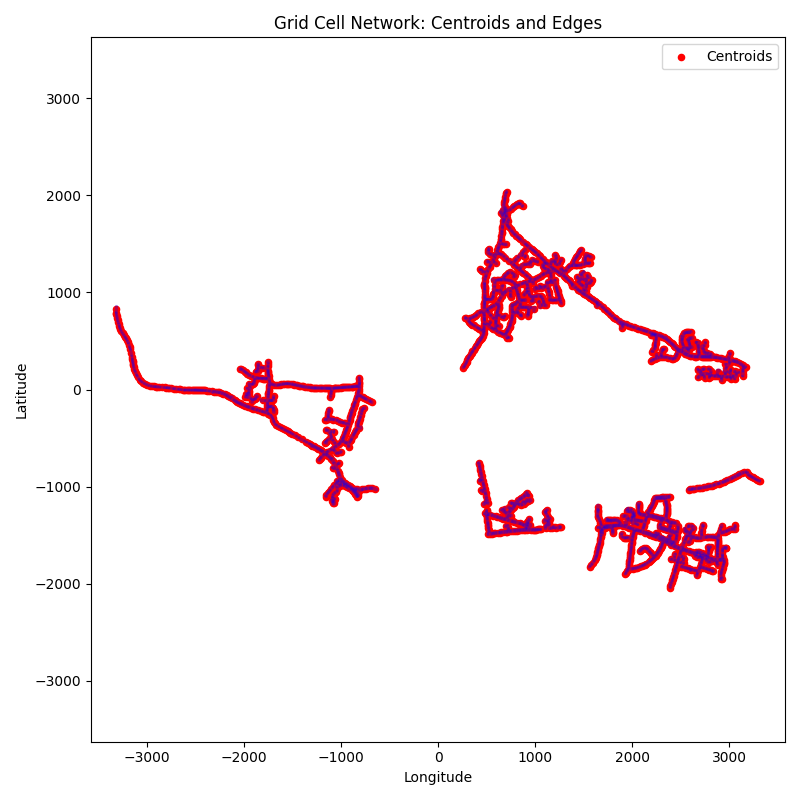

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

# Plot the edges
for u, v in G.edges():
    centroid_u = G.nodes[u]['centroid']
    centroid_v = G.nodes[v]['centroid']
    xs = [centroid_u.x, centroid_v.x]
    ys = [centroid_u.y, centroid_v.y]
    ax.plot(xs, ys, color='grey', linewidth=1, alpha=0.7, zorder=1)

# Plot the centroids
centroids_x = [G.nodes[n]['centroid'].x for n in G.nodes]
centroids_y = [G.nodes[n]['centroid'].y for n in G.nodes]
ax.scatter(centroids_x, centroids_y, color='red', s=20, zorder=2, label='Centroids')
cell_gdf.boundary.plot(ax = ax, color = 'blue', alpha = 0.3)
ax.set_title("Grid Cell Network: Centroids and Edges")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

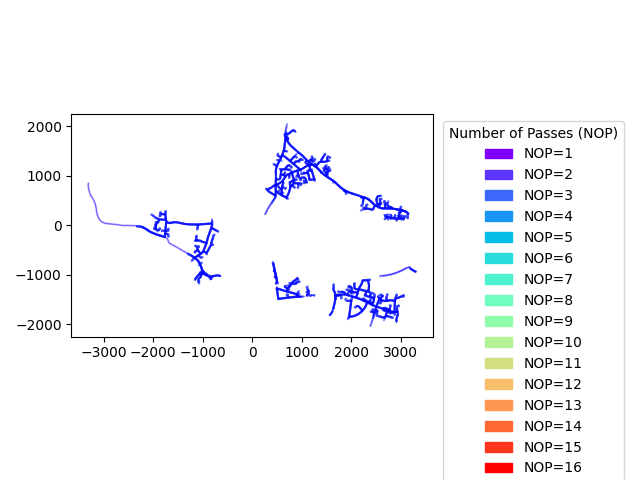

In [22]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Determine min and max NOP values
min_nop = int(cell_gdf['nop'].min())
max_nop = int(cell_gdf['nop'].max())

# Create a list of unique integer NOP values in range (inclusive)
nop_values = list(range(min_nop, max_nop + 1))

# Make the colors more spread using a colormap and normalized spacing
# We'll use np.linspace to spread evenly across the full range of the colormap
spread_cmap = plt.get_cmap('rainbow')  # Viridis is perceptually uniform, good for spreading
num_colors = len(nop_values)

# Calculate equally spaced color positions in [0, 1]
color_positions = np.linspace(0, 1, num_colors)
colors = [spread_cmap(pos) for pos in color_positions]

# Build a mapping from nop value to color
nop_to_color = dict(zip(nop_values, colors))

# Map 'nop' column in cell_gdf to these colors
cell_gdf['nop_color'] = cell_gdf['nop'].astype(int).map(nop_to_color)

fig, ax = plt.subplots()
cell_gdf.plot(color=cell_gdf['nop_color'], ax=ax, linewidth=0.5)
survey_gdf.plot(ax=ax, color='blue', alpha=0.3)

# Create a custom legend for the NOP colors
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color=nop_to_color[nop], label=f"NOP={nop}") for nop in nop_values
]
ax.legend(handles=handles, title='Number of Passes (NOP)', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

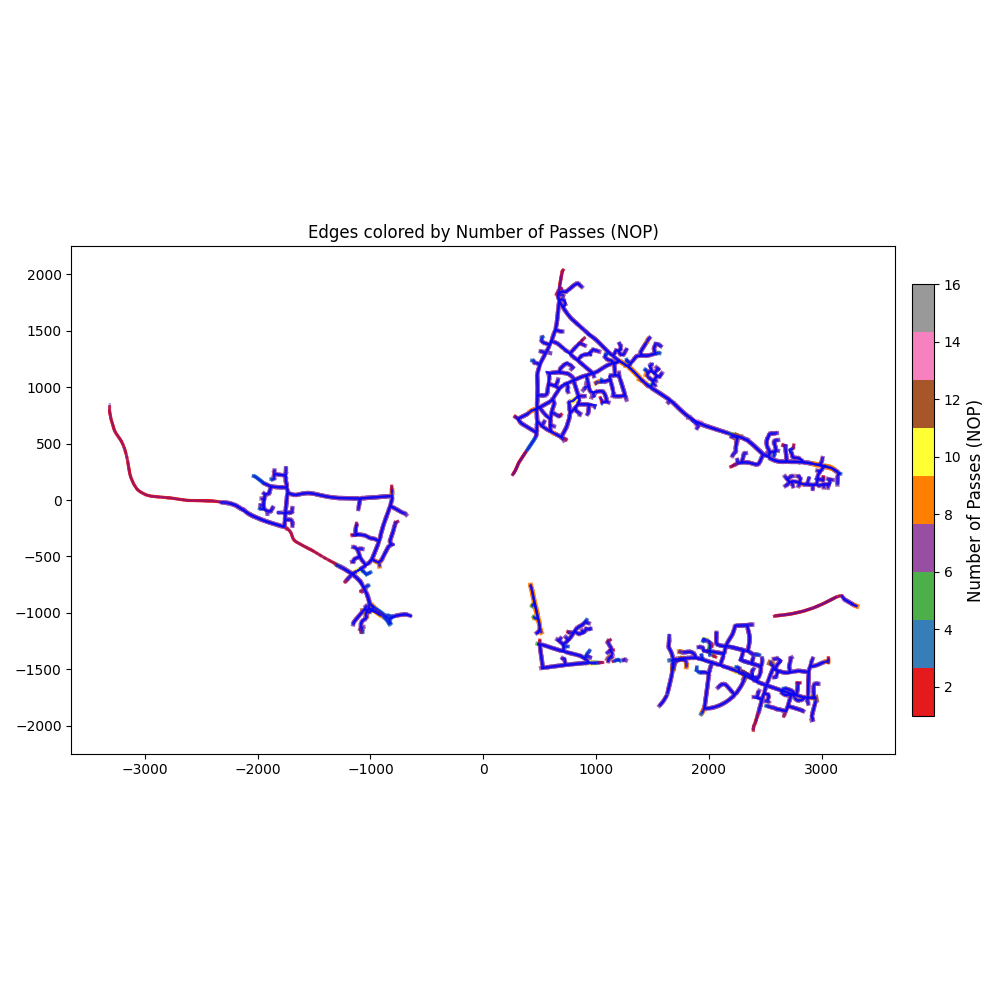

In [23]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the cells for reference/background (optional)
if 'geometry' in cell_gdf.columns:
    cell_gdf.boundary.plot(ax=ax, color='lightgray', linewidth=0.5, alpha=0.7)

# Gather all 'distance' attributes to scale line thickness
edge_distances = [G[u][v].get('distance', 1) for u, v in G.edges()]
max_dist = max(edge_distances) if edge_distances else 1

# Gather all 'numberOfIntersection' to use for line colormap/width
all_nop = [G[u][v].get('numberOfIntersection', 0) for u, v in G.edges()]
max_nop = max(all_nop) if all_nop else 1

# Use a colormap to represent number of passes (nop)
norm = plt.Normalize(vmin=min(all_nop) if all_nop else 0, vmax=max_nop)
cmap = cm.Set1

for u, v in G.edges():
    if 'centroid' in G.nodes[u] and 'centroid' in G.nodes[v]:
        p1 = G.nodes[u]['centroid']
        p2 = G.nodes[v]['centroid']
        # Extract x,y
        x_vals = [p1.x, p2.x]
        y_vals = [p1.y, p2.y]
        nop = G[u][v].get('numberOfIntersection', 0)
        color = cmap(norm(nop))
        linewidth = 2 + 3*(nop / max_nop) if max_nop > 0 else 2
        
        ax.plot(x_vals, y_vals, color=color, linewidth=linewidth, alpha=0.85)
survey_gdf.plot(ax = ax, color = 'blue', alpha = 0.3)

# Create a colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Number of Passes (NOP)', fontsize=12)

ax.set_aspect('equal')
ax.set_title('Edges colored by Number of Passes (NOP)')
plt.tight_layout()
plt.show()